In [4]:
import os
#counting the number of files in train folder
path, dirs, files = next(os.walk('train'))
file_count = len(files)
print('Number of images:', file_count)

Number of images: 22976


### Printing the name of images

In [5]:
file_names = os.listdir('train')
print(file_names)

['cat.10000.jpg', 'cat.10001.jpg', 'cat.10002.jpg', 'cat.10003.jpg', 'cat.10004.jpg', 'cat.10005.jpg', 'cat.10006.jpg', 'cat.10007.jpg', 'cat.10008.jpg', 'cat.10009.jpg', 'cat.10010.jpg', 'cat.10011.jpg', 'cat.10012.jpg', 'cat.10013.jpg', 'cat.10014.jpg', 'cat.10015.jpg', 'cat.10016.jpg', 'cat.10017.jpg', 'cat.10018.jpg', 'cat.10019.jpg', 'cat.10020.jpg', 'cat.10021.jpg', 'cat.10022.jpg', 'cat.10023.jpg', 'cat.10024.jpg', 'cat.10025.jpg', 'cat.10026.jpg', 'cat.10027.jpg', 'cat.10028.jpg', 'cat.10029.jpg', 'cat.10030.jpg', 'cat.10031.jpg', 'cat.10032.jpg', 'cat.10033.jpg', 'cat.10034.jpg', 'cat.10035.jpg', 'cat.10036.jpg', 'cat.10037.jpg', 'cat.10038.jpg', 'cat.10039.jpg', 'cat.10040.jpg', 'cat.10041.jpg', 'cat.10042.jpg', 'cat.10043.jpg', 'cat.10044.jpg', 'cat.10045.jpg', 'cat.10046.jpg', 'cat.10047.jpg', 'cat.10048.jpg', 'cat.10049.jpg', 'cat.10050.jpg', 'cat.10051.jpg', 'cat.10052.jpg', 'cat.10053.jpg', 'cat.10054.jpg', 'cat.10055.jpg', 'cat.10056.jpg', 'cat.10057.jpg', 'cat.10058.jp

### Importing the Dependencies

In [6]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from sklearn.model_selection import train_test_split
import cv2
from opencv_jupyter_ui import cv2_imshow

### Displaying the images of Dogs and Cats

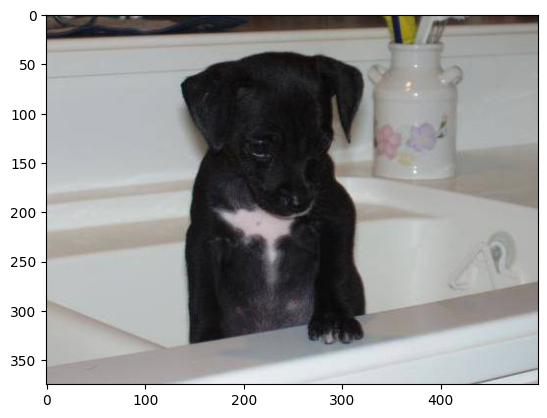

In [7]:
#Display dog image
img = mpimg.imread('train/dog.8298.jpg')
imgplt = plt.imshow(img)
plt.show()

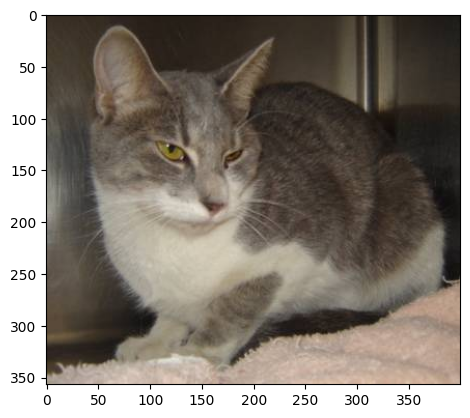

In [8]:
#Display cat image
img = mpimg.imread('train/cat.4352.jpg')
imgplt = plt.imshow(img)
plt.show()

In [9]:
file_names = os.listdir('train')
for i in range(5):
    name = file_names[i]
    print(name[0:3])

cat
cat
cat
cat
cat


In [10]:
file_names = os.listdir('train')

dog_count = 0
cat_count = 0 

for img_file in file_names:
    
    name = img_file[0:3]

    if name == 'dog':
        dog_count += 1
    else:
        cat_count += 1
print('Number of dog images =', dog_count)
print('Number of cat images =', cat_count)

Number of dog images = 11499
Number of cat images = 11477


In [12]:
original_folder = 'Images/'
resized_folder = 'image resized/'

for i in range(2000):
    file_name = os.listdir(original_folder)[i]
    ima_path = original_folder+file_name

    img = Image.open(ima_path)
    img = img.resize((224, 224))
    img = img.convert('RGB')

    newImgPath = resized_folder + file_name
    img.save(newImgPath)

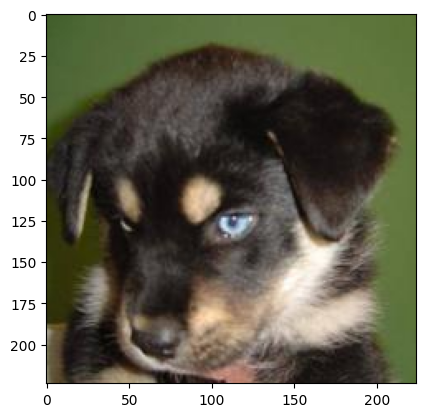

In [14]:
#Display resized dog image
img = mpimg.imread('image resized/dog.998.jpg')
imgplt = plt.imshow(img)
plt.show()

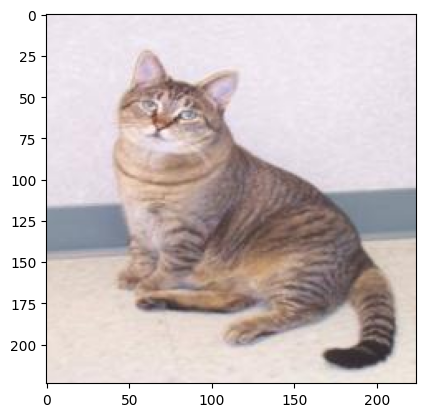

In [15]:
#Display resized cat image
img = mpimg.imread('image resized/cat.998.jpg')
imgplt = plt.imshow(img)
plt.show()

### Creating labels for resized images of dogs and cats

### Creating a for loop to assign labels

In [16]:
filenames = os.listdir('image resized/')

labels = []

for i in range(2000):
    file_name = filenames[i]
    label = file_name[0:3]

    if label == 'dog':
        labels.append(1)
    else:
        labels.append(0)

In [17]:
print(filenames[0:5])
print(len(filenames))

['cat.0.jpg', 'cat.1.jpg', 'cat.10.jpg', 'cat.100.jpg', 'cat.101.jpg']
2000


In [18]:
print(labels[0:5])
print(len(labels))

[0, 0, 0, 0, 0]
2000


### Counting the images of dogs and cats out of 2000 images

In [19]:
values, counts = np.unique(labels, return_counts=True)
print(values)
print(counts)

[0 1]
[1000 1000]


### Converting all the resized images to numpy arrays

In [20]:
import cv2
import glob

In [21]:
image_directory = 'image resized/'
image_extension = ['png','jpg']

files = []

[files.extend(glob.glob(image_directory+'*.' + e)) for e in image_extension]

dog_cat_images = np.asarray([cv2.imread(file) for file in files])

In [23]:
print(dog_cat_images)

[[[[ 87 163 205]
   [ 89 165 207]
   [ 92 168 210]
   ...
   [124 203 246]
   [122 200 246]
   [122 200 246]]

  [[ 87 163 205]
   [ 89 165 207]
   [ 92 168 210]
   ...
   [124 203 246]
   [123 201 247]
   [122 200 246]]

  [[ 87 163 205]
   [ 89 165 207]
   [ 92 168 210]
   ...
   [124 204 245]
   [123 202 245]
   [123 202 245]]

  ...

  [[ 55 123 160]
   [ 55 123 160]
   [ 56 124 161]
   ...
   [  0   1   1]
   [  0   1   1]
   [  0   1   1]]

  [[ 53 121 158]
   [ 54 122 159]
   [ 55 123 160]
   ...
   [  0   1   1]
   [  0   1   1]
   [  0   1   1]]

  [[ 52 120 157]
   [ 52 120 157]
   [ 53 121 158]
   ...
   [  0   1   1]
   [  0   1   1]
   [  0   1   1]]]


 [[[ 43  43  37]
   [ 47  47  41]
   [ 47  47  41]
   ...
   [185 205 210]
   [173 197 203]
   [164 192 199]]

  [[ 42  42  36]
   [ 46  46  40]
   [ 45  45  39]
   ...
   [180 200 205]
   [169 195 201]
   [167 195 202]]

  [[ 42  42  36]
   [ 44  44  38]
   [ 43  43  37]
   ...
   [172 192 197]
   [167 193 200]
   [171 198

In [24]:
type(dog_cat_images)

numpy.ndarray

In [25]:
print(dog_cat_images.shape)

(2000, 224, 224, 3)


In [26]:
X = dog_cat_images
Y = np.asarray(labels)

### Train_test_split

In [27]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=2)

In [28]:
print(X.shape,X_train.shape,X_test.shape)

(2000, 224, 224, 3) (1600, 224, 224, 3) (400, 224, 224, 3)


### Scaling the Data

In [29]:
X_train_scaled = X_train/255
X_test_scaled = X_test/255

In [30]:
print(X_train_scaled)

[[[[0.77647059 0.79607843 0.78823529]
   [0.77647059 0.79607843 0.78823529]
   [0.77647059 0.79607843 0.78823529]
   ...
   [0.84705882 0.85098039 0.84313725]
   [0.84705882 0.85098039 0.84313725]
   [0.84705882 0.85098039 0.84313725]]

  [[0.77647059 0.79607843 0.78823529]
   [0.77647059 0.79607843 0.78823529]
   [0.77647059 0.79607843 0.78823529]
   ...
   [0.83529412 0.83921569 0.83137255]
   [0.83529412 0.83921569 0.83137255]
   [0.83529412 0.83921569 0.83137255]]

  [[0.77647059 0.79607843 0.78823529]
   [0.77647059 0.79607843 0.78823529]
   [0.77647059 0.79607843 0.78823529]
   ...
   [0.82745098 0.83137255 0.82352941]
   [0.82352941 0.82745098 0.81960784]
   [0.82352941 0.82745098 0.81960784]]

  ...

  [[0.74901961 0.75686275 0.76078431]
   [0.74509804 0.75294118 0.75686275]
   [0.73333333 0.74117647 0.74509804]
   ...
   [0.74509804 0.74901961 0.74117647]
   [0.74509804 0.74901961 0.74117647]
   [0.74509804 0.74901961 0.74117647]]

  [[0.76862745 0.77647059 0.78039216]
   [0.7

### Building the Neural Network

In [33]:
import tensorflow as tf
import tensorflow_hub as hub

In [41]:
mobilenet_model = 'https://tfhub.dev/google/tf2-preview/mobilenet_v2/feature_vector/4'
pretrained_model = hub.KerasLayer(mobilenet_model, input_shape=(224, 224, 3),trainable=False)

In [49]:
um_of_classes = 2

# Load pretrained model
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet',
    pooling='avg'
)

# Freeze base model
base_model.trainable = False

# Build model
model = tf.keras.Sequential([
    base_model,
    tf.keras.layers.Dense(num_of_classes, activation='softmax')
])

model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224 (Functional)    │ (None, 1280)                │       2,257,984 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (None, 2)                   │           2,562 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,260,546 (8.62 MB)

 Trainable params: 2,562 (10.01 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [50]:
model.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['acc']
)

In [51]:
model.fit(X_train_scaled, Y_train, epochs=5)

Epoch 1/5


C:\Users\kamale.nagaraj\AppData\Roaming\Python\Python311\site-packages\keras\src\backend\tensorflow\nn.py:1214: UserWarning: "`sparse_categorical_crossentropy` received `from_logits=True`, but the `output` argument was produced by a Softmax activation and thus does not represent logits. Was this intended?


50/50 ━━━━━━━━━━━━━━━━━━━━ 29s 414ms/step - acc: 0.9112 - loss: 0.2010
Epoch 2/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 24s 482ms/step - acc: 0.9656 - loss: 0.0886
Epoch 3/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 23s 454ms/step - acc: 0.9769 - loss: 0.0652
Epoch 4/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 20s 395ms/step - acc: 0.9825 - loss: 0.0502
Epoch 5/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 24s 482ms/step - acc: 0.9856 - loss: 0.0435


In [52]:
score, acc = model.evaluate(X_test_scaled, Y_test)
print('Test Loss =', score)
print('Test Accuracy =', acc)

C:\Users\kamale.nagaraj\AppData\Roaming\Python\Python311\site-packages\keras\src\backend\tensorflow\nn.py:1214: UserWarning: "`sparse_categorical_crossentropy` received `from_logits=True`, but the `output` argument was produced by a Softmax activation and thus does not represent logits. Was this intended?


13/13 ━━━━━━━━━━━━━━━━━━━━ 7s 367ms/step - acc: 0.9775 - loss: 0.0638
Test Loss = 0.06384892016649246
Test Accuracy = 0.9775000214576721


### Predictive System

Path of the image to be predicted:  C:\Users\kamale.nagaraj\Downloads\dog.jpg


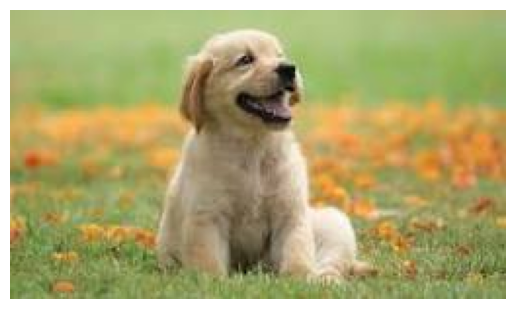

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
[[0.00539972 0.9946003 ]]
1
The image represents a Dog


In [55]:
input_img_path = input('Path of the image to be predicted: ')

input_image = cv2.imread(input_img_path)

# Safety check
if input_image is None:
    print("Error: Image not found. Check path.")
    exit()

# Display image
input_image_rgb = cv2.cvtColor(input_image, cv2.COLOR_BGR2RGB)
plt.imshow(input_image_rgb)
plt.axis('off')
plt.show()

# Preprocessing
input_image_resize = cv2.resize(input_image, (224, 224))
input_image_scaled = input_image_resize / 255.0

image_reshaped = np.reshape(input_image_scaled, [1, 224, 224, 3])

# Prediction
input_prediction = model.predict(image_reshaped)

print(input_prediction)

input_pred_label = np.argmax(input_prediction)

print(input_pred_label)

if input_pred_label == 0:
    print('The image represents a Cat')
else:
    print('The image represents a Dog')

Path of the image to be predicted:  C:\Users\kamale.nagaraj\Downloads\cat.jpg


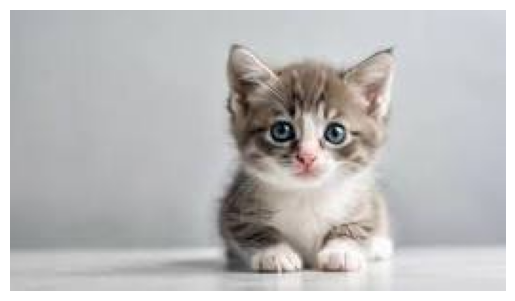

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step
[[9.9995494e-01 4.5009216e-05]]
0
The image represents a Cat


In [56]:
input_img_path = input('Path of the image to be predicted: ')

input_image = cv2.imread(input_img_path)

# Safety check
if input_image is None:
    print("Error: Image not found. Check path.")
    exit()

# Display image
input_image_rgb = cv2.cvtColor(input_image, cv2.COLOR_BGR2RGB)
plt.imshow(input_image_rgb)
plt.axis('off')
plt.show()

# Preprocessing
input_image_resize = cv2.resize(input_image, (224, 224))
input_image_scaled = input_image_resize / 255.0

image_reshaped = np.reshape(input_image_scaled, [1, 224, 224, 3])

# Prediction
input_prediction = model.predict(image_reshaped)

print(input_prediction)

input_pred_label = np.argmax(input_prediction)

print(input_pred_label)

if input_pred_label == 0:
    print('The image represents a Cat')
else:
    print('The image represents a Dog')